# ADHD EEG Classification — Multiple Seeds Fixed Version

Оваа верзија го заменува `one lucky guess` пристапот со повторување преку повеќе seeds. За секој seed се прави subject-wise train/test split, DataLoader shuffle, model initialization и training. Финалниот резултат е mean ± std.

In [ ]:
import os
import sys
import random
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import butter, filtfilt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")
print("PyTorch:", torch.__version__)


Libraries imported successfully.
PyTorch: 2.10.0+cu128


In [ ]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


## Dataset Path + Structure Check

In [145]:
print(os.listdir("/kaggle/input"))


['datasets']


In [146]:
BASE_PATH = "/kaggle/input/datasets/dannasalazar11/children-adhd-database"
ADHD_PATH = os.path.join(BASE_PATH, "ADHD_group")
CONTROL_PATH = os.path.join(BASE_PATH, "Control_group")

print("ADHD path exists:", os.path.exists(ADHD_PATH))
print("Control path exists:", os.path.exists(CONTROL_PATH))
print("ADHD files:", len(os.listdir(ADHD_PATH)))
print("Control files:", len(os.listdir(CONTROL_PATH)))


ADHD path exists: True
Control path exists: True
ADHD files: 61
Control files: 60


# Load ADHD + Control Subjects

In [ ]:
def load_subjects_from_folder(folder_path, label):
    X, y, subject_ids = [], [], []
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".mat")])

    for file in files:
        file_path = os.path.join(folder_path, file)
        try:
            mat_data = sio.loadmat(file_path)
            available_keys = [k for k in mat_data.keys() if not k.startswith("__")]
            eeg_key = available_keys[0]
            eeg_signal = mat_data[eeg_key]

            if eeg_signal.shape[0] < eeg_signal.shape[1]:
                eeg_signal = eeg_signal.T

            X.append(eeg_signal.astype(np.float32))
            y.append(label)
            subject_ids.append(file.replace(".mat", ""))
        except Exception as e:
            print(f"Error loading {file}: {e}")

    return X, y, subject_ids


X_adhd, y_adhd, id_adhd = load_subjects_from_folder(ADHD_PATH, label=1)
X_control, y_control, id_control = load_subjects_from_folder(CONTROL_PATH, label=0)

X = X_adhd + X_control
y = np.array(y_adhd + y_control)
subject_ids = np.array(id_adhd + id_control)

subject_df = pd.DataFrame({"subject_id": subject_ids, "label": y})

print("Total subjects loaded:", len(X))
print("ADHD subjects:", len(X_adhd))
print("Control subjects:", len(X_control))
print("Subject-level labels:")
print(subject_df["label"].value_counts())


Total subjects loaded: 121
ADHD subjects: 61
Control subjects: 60
Subject-level labels:
label
1    61
0    60
Name: count, dtype: int64


In [148]:
shape_df = pd.DataFrame({
    "subject_id": subject_ids,
    "label": y,
    "shape": [signal.shape for signal in X]
})

display(shape_df.head(10))
print("Unique EEG shapes:")
print(shape_df["shape"].value_counts())

example_idx = 0
print("Example subject:", subject_ids[example_idx])
print("Label:", y[example_idx])
print("Shape:", X[example_idx].shape)
print("Min/Max/Mean:", np.min(X[example_idx]), np.max(X[example_idx]), np.mean(X[example_idx]))


,subject_id,label,shape
0,v10p,1,"(14304, 19)"
1,v12p,1,"(17604, 19)"
2,v14p,1,"(17562, 19)"
3,v15p,1,"(43252, 19)"
4,v173,1,"(24241, 19)"
5,v177,1,"(16697, 19)"
6,v179,1,"(12673, 19)"
7,v181,1,"(10668, 19)"
8,v183,1,"(18591, 19)"
9,v18p,1,"(25003, 19)"


Unique EEG shapes:
shape
(14304, 19)    1
(17604, 19)    1
(17562, 19)    1
(43252, 19)    1
(24241, 19)    1
              ..
(14139, 19)    1
(14692, 19)    1
(13918, 19)    1
(16513, 19)    1
(12929, 19)    1
Name: count, Length: 121, dtype: int64
Example subject: v10p
Label: 1
Shape: (14304, 19)
Min/Max/Mean: -2208.0 4802.0 149.6931


# Preprocessing

In [149]:
FS = 128
LOWCUT = 1.0
HIGHCUT = 40.0
WINDOW_SECONDS = 4
WINDOW_SIZE = FS * WINDOW_SECONDS
OVERLAP = 0.5
STEP_SIZE = int(WINDOW_SIZE * (1 - OVERLAP))

NUM_CHANNELS = 19
BATCH_SIZE = 32
THRESHOLD = 0.55

print("Sampling rate:", FS)
print("Window size:", WINDOW_SIZE)
print("Step size:", STEP_SIZE)


Sampling rate: 128
Window size: 512
Step size: 256


In [150]:
def bandpass_filter(signal, fs=128, lowcut=1.0, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal, axis=0)


def zscore_normalize(signal):
    mean = np.mean(signal, axis=0, keepdims=True)
    std = np.std(signal, axis=0, keepdims=True)
    std[std == 0] = 1e-8
    return (signal - mean) / std


def segment_signal(signal, window_size=512, step_size=256):
    windows = []
    num_samples = signal.shape[0]
    for start in range(0, num_samples - window_size + 1, step_size):
        end = start + window_size
        windows.append(signal[start:end, :])
    return np.array(windows, dtype=np.float32)


In [151]:
X_windows_list = []
y_windows = []
subject_window_ids = []

for signal, label, subject_id in zip(X, y, subject_ids):
    filtered = bandpass_filter(signal, fs=FS, lowcut=LOWCUT, highcut=HIGHCUT)
    normalized = zscore_normalize(filtered)
    windows = segment_signal(normalized, window_size=WINDOW_SIZE, step_size=STEP_SIZE)

    X_windows_list.append(windows)
    y_windows.extend([label] * len(windows))
    subject_window_ids.extend([subject_id] * len(windows))

X_windows = np.concatenate(X_windows_list, axis=0).astype(np.float32)
y_windows = np.array(y_windows).astype(np.float32)
subject_window_ids = np.array(subject_window_ids)

print("Preprocessing completed.")
print("X_windows shape:", X_windows.shape)
print("y_windows shape:", y_windows.shape)
print("subject_window_ids shape:", subject_window_ids.shape)
print("Window-level class distribution:")
print(pd.Series(y_windows).value_counts())
print("Unique subjects:", len(np.unique(subject_window_ids)))


Preprocessing completed.
X_windows shape: (8279, 512, 19)
y_windows shape: (8279,)
subject_window_ids shape: (8279,)
Window-level class distribution:
1.0    4622
0.0    3657
Name: count, dtype: int64
Unique subjects: 121


# Multiple-seed subject-wise split + DataLoaders

In [ ]:
def make_seed_data(seed, batch_size=BATCH_SIZE):
    """For each seed: subject-wise stratified split + tensors + loaders."""
    set_seed(seed)

    train_subjects, test_subjects = train_test_split(
        subject_df["subject_id"].values,
        test_size=0.2,
        random_state=seed,
        stratify=subject_df["label"].values
    )

    train_mask = np.isin(subject_window_ids, train_subjects)
    test_mask = np.isin(subject_window_ids, test_subjects)

    X_train = X_windows[train_mask]
    y_train = y_windows[train_mask]
    subjects_train = subject_window_ids[train_mask]

    X_test = X_windows[test_mask]
    y_test = y_windows[test_mask]
    subjects_test = subject_window_ids[test_mask]

    assert len(set(subjects_train).intersection(set(subjects_test))) == 0, "Subject leakage detected!"

    X_train_eeg = np.transpose(X_train, (0, 2, 1))[:, np.newaxis, :, :]
    X_test_eeg = np.transpose(X_test, (0, 2, 1))[:, np.newaxis, :, :]

    X_train_tensor = torch.tensor(X_train_eeg, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_eeg, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        worker_init_fn=seed_worker,
        generator=g,
        num_workers=0
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    split_info = {
        "seed": seed,
        "train_subjects": len(np.unique(subjects_train)),
        "test_subjects": len(np.unique(subjects_test)),
        "train_windows": len(X_train_tensor),
        "test_windows": len(X_test_tensor),
        "train_adhd_windows": int(np.sum(y_train == 1)),
        "train_control_windows": int(np.sum(y_train == 0)),
        "test_adhd_windows": int(np.sum(y_test == 1)),
        "test_control_windows": int(np.sum(y_test == 0)),
    }

    return train_loader, test_loader, split_info


_tmp_train_loader, _tmp_test_loader, _tmp_info = make_seed_data(42)
print(_tmp_info)
X_debug, y_debug = next(iter(_tmp_train_loader))
print("Batch shape:", X_debug.shape, y_debug.shape)


{'seed': 42, 'train_subjects': 96, 'test_subjects': 25, 'train_windows': 6619, 'test_windows': 1660, 'train_adhd_windows': 3722, 'train_control_windows': 2897, 'test_adhd_windows': 900, 'test_control_windows': 760}
Batch shape: torch.Size([32, 1, 19, 512]) torch.Size([32])


# EEGNet Model

In [153]:
class EEGNet(nn.Module):
    def __init__(self, num_channels=19, num_samples=512, dropout_rate=0.5):
        super().__init__()

        self.firstconv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(8)
        )

        self.depthwiseConv = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=(num_channels, 1), groups=8, bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout_rate)
        )

        self.separableConv = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout_rate)
        )

        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, num_channels, num_samples)
            dummy_output = self.separableConv(self.depthwiseConv(self.firstconv(dummy_input)))
            flatten_size = dummy_output.reshape(1, -1).shape[1]

        self.classifier = nn.Linear(flatten_size, 1)

    def forward(self, x):
        x = self.firstconv(x)
        x = self.depthwiseConv(x)
        x = self.separableConv(x)
        x = x.reshape(x.size(0), -1)
        x = self.classifier(x)
        return x.squeeze(1)


print(EEGNet(num_channels=NUM_CHANNELS, num_samples=WINDOW_SIZE))


EEGNet(
  (firstconv): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (depthwiseConv): Sequential(
    (0): Conv2d(8, 16, kernel_size=(19, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (separableConv): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)


# Training / Evaluation Functions

In [154]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate_model(model, loader, device, threshold=THRESHOLD):
    model.eval()
    all_scores, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            scores = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            all_scores.extend(scores)
            all_labels.extend(y_batch.numpy().reshape(-1))

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels).astype(int)
    preds = (all_scores > threshold).astype(int)

    acc = accuracy_score(all_labels, preds)
    prec = precision_score(all_labels, preds, zero_division=0)
    rec = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    cm = confusion_matrix(all_labels, preds)

    return acc, prec, rec, f1, cm, all_scores, all_labels, preds


def train_model_with_seed(
    model_class,
    model_name,
    seed,
    epochs=100,
    lr=0.001,
    threshold=THRESHOLD,
    model_kwargs=None,
    fix_function=None
):
    set_seed(seed)
    train_loader, test_loader, split_info = make_seed_data(seed, batch_size=BATCH_SIZE)

    if model_kwargs is None:
        model_kwargs = {}

    model = model_class(**model_kwargs).to(DEVICE)

    if fix_function is not None:
        model = fix_function(model)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_f1 = -1.0
    best_results = None
    best_scores_df = None
    best_model_path = f"best_{model_name}_seed_{seed}.pth"

    history = []

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        acc, prec, rec, f1, cm, scores, labels, preds = evaluate_model(model, test_loader, DEVICE, threshold)

        history.append({
            "model": model_name,
            "seed": seed,
            "epoch": epoch,
            "train_loss": train_loss,
            "test_accuracy": acc,
            "test_precision": prec,
            "test_recall": rec,
            "test_f1": f1,
        })

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), best_model_path)
            best_results = {
                "model": model_name,
                "seed": seed,
                "best_epoch": epoch,
                "accuracy": acc,
                "precision": prec,
                "recall": rec,
                "f1": f1,
                "best_model_path": best_model_path,
                **split_info
            }
            best_scores_df = pd.DataFrame({
                "model": model_name,
                "seed": seed,
                "true_label": labels,
                "adhd_score": scores,
                "predicted_label": preds,
            })

        print(
            f"{model_name} | seed {seed} | epoch {epoch:03d}/{epochs} | "
            f"loss {train_loss:.4f} | acc {acc:.4f} | prec {prec:.4f} | rec {rec:.4f} | f1 {f1:.4f}"
        )

    history_df = pd.DataFrame(history)
    history_df.to_csv(f"{model_name}_history_seed_{seed}.csv", index=False)
    best_scores_df.to_csv(f"{model_name}_scores_seed_{seed}.csv", index=False)

    return best_results, history_df, best_scores_df


# Train EEGNet with Multiple Seeds

In [155]:
SEEDS = [42, 123, 2024, 7, 999]
EEGNET_EPOCHS = 100

eegnet_seed_results = []
eegnet_histories = {}
eegnet_scores = {}

for seed in SEEDS:
    result, hist, scores_df = train_model_with_seed(
        model_class=EEGNet,
        model_name="eegnet",
        seed=seed,
        epochs=EEGNET_EPOCHS,
        lr=0.001,
        threshold=THRESHOLD,
        model_kwargs={
            "num_channels": NUM_CHANNELS,
            "num_samples": WINDOW_SIZE,
            "dropout_rate": 0.5
        }
    )
    eegnet_seed_results.append(result)
    eegnet_histories[seed] = hist
    eegnet_scores[seed] = scores_df

eegnet_seed_results_df = pd.DataFrame(eegnet_seed_results)
eegnet_seed_results_df.to_csv("eegnet_seed_results.csv", index=False)
display(eegnet_seed_results_df)


eegnet | seed 42 | epoch 001/100 | loss 0.6348 | acc 0.6494 | prec 0.7114 | rec 0.5944 | f1 0.6477
eegnet | seed 42 | epoch 002/100 | loss 0.4700 | acc 0.5928 | prec 0.7205 | rec 0.4067 | f1 0.5199
eegnet | seed 42 | epoch 003/100 | loss 0.3825 | acc 0.6349 | prec 0.7625 | rec 0.4744 | f1 0.5849
eegnet | seed 42 | epoch 004/100 | loss 0.3388 | acc 0.6735 | prec 0.7680 | rec 0.5700 | f1 0.6543
eegnet | seed 42 | epoch 005/100 | loss 0.3119 | acc 0.6494 | prec 0.7524 | rec 0.5267 | f1 0.6196
eegnet | seed 42 | epoch 006/100 | loss 0.2869 | acc 0.6596 | prec 0.7417 | rec 0.5711 | f1 0.6453
eegnet | seed 42 | epoch 007/100 | loss 0.2777 | acc 0.6699 | prec 0.7611 | rec 0.5700 | f1 0.6518
eegnet | seed 42 | epoch 008/100 | loss 0.2543 | acc 0.6747 | prec 0.7579 | rec 0.5878 | f1 0.6621
eegnet | seed 42 | epoch 009/100 | loss 0.2451 | acc 0.6657 | prec 0.7461 | rec 0.5811 | f1 0.6533
eegnet | seed 42 | epoch 010/100 | loss 0.2260 | acc 0.7072 | prec 0.7556 | rec 0.6800 | f1 0.7158
eegnet | s

,model,seed,best_epoch,accuracy,precision,recall,f1,best_model_path,train_subjects,test_subjects,train_windows,test_windows,train_adhd_windows,train_control_windows,test_adhd_windows,test_control_windows
0,eegnet,42,24,0.746988,0.803030,0.706667,0.751773,best_eegnet_seed_42.pth,96,25,6619,1660,3722,2897,900,760
1,eegnet,123,99,0.804910,0.797945,0.848301,0.822353,best_eegnet_seed_123.pth,96,25,6731,1548,3798,2933,824,724
2,eegnet,2024,44,0.749567,0.715342,0.860000,0.781029,best_eegnet_seed_2024.pth,96,25,6546,1733,3722,2824,900,833
3,eegnet,7,49,0.808831,0.869818,0.824038,0.846309,best_eegnet_seed_7.pth,96,25,6286,1993,3349,2937,1273,720
4,eegnet,999,69,0.782486,0.788085,0.871940,0.827895,best_eegnet_seed_999.pth,96,25,6509,1770,3560,2949,1062,708


In [156]:
eegnet_summary = eegnet_seed_results_df[["accuracy", "precision", "recall", "f1"]].agg(["mean", "std"])
eegnet_summary.to_csv("eegnet_summary_mean_std.csv")
display(eegnet_summary)


,accuracy,precision,recall,f1
mean,0.778556,0.794844,0.822189,0.805872
std,0.029425,0.054918,0.066962,0.038521


# NeuroGPT Setup

In [157]:
if not os.path.exists("/kaggle/working/NeuroGPT"):
    subprocess.run(["git", "clone", "https://github.com/wenhui0206/NeuroGPT.git", "/kaggle/working/NeuroGPT"], check=True)
else:
    print("NeuroGPT already exists.")

NEUROGPT_SRC_PATH = "/kaggle/working/NeuroGPT/src"
if NEUROGPT_SRC_PATH not in sys.path:
    sys.path.append(NEUROGPT_SRC_PATH)

from encoder.conformer_braindecode import EEGConformer
print("EEGConformer imported successfully.")


Cloning into '/kaggle/working/NeuroGPT'...


EEGConformer imported successfully.


In [ ]:
class NeuroGPT_ADHD(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = EEGConformer(
            n_outputs=1,
            n_chans=NUM_CHANNELS,
            n_times=WINDOW_SIZE,
            is_decoding_mode=True
        )

    def forward(self, x):
        if x.dim() == 4:
            x = x.squeeze(1)       
        x = x.unsqueeze(1)         
        out = self.encoder(x)
        return out.reshape(-1)


class NeuroGPTFixedFC(nn.Module):
    def __init__(self, input_dim, out_channels=256, hidden_channels=32, dropout=0.5):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, out_channels),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(out_channels, hidden_channels),
            nn.ELU()
        )

    def forward(self, x):
        x = x.contiguous().reshape(x.size(0), -1)
        return self.fc(x)


def detect_neurogpt_feature_dim(model):
    model.eval()
    with torch.no_grad():
        x_debug = torch.zeros(2, 1, NUM_CHANNELS, WINDOW_SIZE).to(DEVICE)
        x_debug = x_debug.squeeze(1).unsqueeze(1)

        batch, chunks, chann, time = x_debug.size()
        x_tmp = x_debug.contiguous().view(batch * chunks, chann, time)
        x_tmp = torch.unsqueeze(x_tmp, dim=1)
        x_tmp = model.encoder.patch_embedding(x_tmp)
        x_tmp = model.encoder.transformer(x_tmp)
        input_dim = x_tmp.contiguous().view(x_tmp.size(0), -1).shape[1]
    return input_dim


def fix_neurogpt_model(model):
    input_dim = detect_neurogpt_feature_dim(model)
    print("Detected NeuroGPT feature dimension:", input_dim)

    model.encoder.fc = NeuroGPTFixedFC(
        input_dim=input_dim,
        out_channels=256,
        hidden_channels=32,
        dropout=0.5
    ).to(DEVICE)

    model.encoder.final_layer.final_layer = nn.Sequential(
        nn.Linear(32, 1)
    ).to(DEVICE)

    return model


_tmp_model = fix_neurogpt_model(NeuroGPT_ADHD().to(DEVICE))
_tmp_x, _tmp_y = next(iter(_tmp_train_loader))
with torch.no_grad():
    _tmp_out = _tmp_model(_tmp_x[:4].to(DEVICE))
print("NeuroGPT test output shape:", _tmp_out.shape)


FC Layer for Classification created.
Detected NeuroGPT feature dimension: 1120
NeuroGPT test output shape: torch.Size([4])


/kaggle/working/NeuroGPT/src/encoder/base.py:178: UserWarning: LogSoftmax final layer will be removed! Please adjust your loss function accordingly (e.g. CrossEntropyLoss)!
  warnings.warn("LogSoftmax final layer will be removed! " +


# Train NeuroGPT with Multiple Seeds

In [159]:
NEUROGPT_EPOCHS = 100

neurogpt_seed_results = []
neurogpt_histories = {}
neurogpt_scores = {}

for seed in SEEDS:
    result, hist, scores_df = train_model_with_seed(
        model_class=NeuroGPT_ADHD,
        model_name="neurogpt",
        seed=seed,
        epochs=NEUROGPT_EPOCHS,
        lr=0.0005,
        threshold=THRESHOLD,
        model_kwargs={},
        fix_function=fix_neurogpt_model
    )
    neurogpt_seed_results.append(result)
    neurogpt_histories[seed] = hist
    neurogpt_scores[seed] = scores_df

neurogpt_seed_results_df = pd.DataFrame(neurogpt_seed_results)
neurogpt_seed_results_df.to_csv("neurogpt_seed_results.csv", index=False)
display(neurogpt_seed_results_df)


FC Layer for Classification created.
Detected NeuroGPT feature dimension: 1120


/kaggle/working/NeuroGPT/src/encoder/base.py:178: UserWarning: LogSoftmax final layer will be removed! Please adjust your loss function accordingly (e.g. CrossEntropyLoss)!
  warnings.warn("LogSoftmax final layer will be removed! " +


neurogpt | seed 42 | epoch 001/100 | loss 0.5517 | acc 0.7410 | prec 0.6926 | rec 0.9389 | f1 0.7972
neurogpt | seed 42 | epoch 002/100 | loss 0.3594 | acc 0.7169 | prec 0.7494 | rec 0.7178 | f1 0.7333
neurogpt | seed 42 | epoch 003/100 | loss 0.2695 | acc 0.7253 | prec 0.6910 | rec 0.8922 | f1 0.7789
neurogpt | seed 42 | epoch 004/100 | loss 0.2059 | acc 0.6849 | prec 0.7887 | rec 0.5722 | f1 0.6632
neurogpt | seed 42 | epoch 005/100 | loss 0.1544 | acc 0.7145 | prec 0.7871 | rec 0.6489 | f1 0.7113
neurogpt | seed 42 | epoch 006/100 | loss 0.1271 | acc 0.7265 | prec 0.7148 | rec 0.8244 | f1 0.7657
neurogpt | seed 42 | epoch 007/100 | loss 0.1245 | acc 0.7729 | prec 0.8409 | rec 0.7167 | f1 0.7738
neurogpt | seed 42 | epoch 008/100 | loss 0.1030 | acc 0.7120 | prec 0.6623 | rec 0.9567 | f1 0.7827
neurogpt | seed 42 | epoch 009/100 | loss 0.1041 | acc 0.7572 | prec 0.7802 | rec 0.7689 | f1 0.7745
neurogpt | seed 42 | epoch 010/100 | loss 0.0706 | acc 0.7633 | prec 0.8014 | rec 0.7489 | 

/kaggle/working/NeuroGPT/src/encoder/base.py:178: UserWarning: LogSoftmax final layer will be removed! Please adjust your loss function accordingly (e.g. CrossEntropyLoss)!
  warnings.warn("LogSoftmax final layer will be removed! " +


neurogpt | seed 123 | epoch 001/100 | loss 0.5639 | acc 0.6615 | prec 0.6119 | rec 0.9951 | f1 0.7579
neurogpt | seed 123 | epoch 002/100 | loss 0.4357 | acc 0.6602 | prec 0.6166 | rec 0.9563 | f1 0.7498
neurogpt | seed 123 | epoch 003/100 | loss 0.3304 | acc 0.6473 | prec 0.6125 | rec 0.9187 | f1 0.7350
neurogpt | seed 123 | epoch 004/100 | loss 0.2406 | acc 0.6925 | prec 0.6482 | rec 0.9235 | f1 0.7618
neurogpt | seed 123 | epoch 005/100 | loss 0.1867 | acc 0.7074 | prec 0.6835 | rec 0.8386 | f1 0.7531
neurogpt | seed 123 | epoch 006/100 | loss 0.1643 | acc 0.7242 | prec 0.8059 | rec 0.6347 | f1 0.7101
neurogpt | seed 123 | epoch 007/100 | loss 0.1255 | acc 0.6757 | prec 0.6315 | rec 0.9381 | f1 0.7549
neurogpt | seed 123 | epoch 008/100 | loss 0.1143 | acc 0.6899 | prec 0.6483 | rec 0.9126 | f1 0.7581
neurogpt | seed 123 | epoch 009/100 | loss 0.0892 | acc 0.7403 | prec 0.7180 | rec 0.8434 | f1 0.7757
neurogpt | seed 123 | epoch 010/100 | loss 0.0903 | acc 0.6563 | prec 0.6106 | rec

...

/kaggle/working/NeuroGPT/src/encoder/base.py:178: UserWarning: LogSoftmax final layer will be removed! Please adjust your loss function accordingly (e.g. CrossEntropyLoss)!
  warnings.warn("LogSoftmax final layer will be removed! " +


neurogpt | seed 7 | epoch 001/100 | loss 0.5594 | acc 0.8128 | prec 0.8478 | rec 0.8617 | f1 0.8547
neurogpt | seed 7 | epoch 002/100 | loss 0.3613 | acc 0.5148 | prec 0.7593 | rec 0.3519 | f1 0.4809
neurogpt | seed 7 | epoch 003/100 | loss 0.2775 | acc 0.6217 | prec 0.7849 | rec 0.5617 | f1 0.6548
neurogpt | seed 7 | epoch 004/100 | loss 0.2100 | acc 0.6312 | prec 0.8022 | rec 0.5609 | f1 0.6602
neurogpt | seed 7 | epoch 005/100 | loss 0.1530 | acc 0.7998 | prec 0.8372 | rec 0.8523 | f1 0.8447
neurogpt | seed 7 | epoch 006/100 | loss 0.1457 | acc 0.6588 | prec 0.8054 | rec 0.6143 | f1 0.6970
neurogpt | seed 7 | epoch 007/100 | loss 0.1458 | acc 0.7416 | prec 0.8137 | rec 0.7722 | f1 0.7924
neurogpt | seed 7 | epoch 008/100 | loss 0.1012 | acc 0.8445 | prec 0.8247 | rec 0.9607 | f1 0.8875
neurogpt | seed 7 | epoch 009/100 | loss 0.0962 | acc 0.7030 | prec 0.8342 | rec 0.6677 | f1 0.7417
neurogpt | seed 7 | epoch 010/100 | loss 0.0769 | acc 0.7240 | prec 0.8326 | rec 0.7109 | f1 0.7669


/kaggle/working/NeuroGPT/src/encoder/base.py:178: UserWarning: LogSoftmax final layer will be removed! Please adjust your loss function accordingly (e.g. CrossEntropyLoss)!
  warnings.warn("LogSoftmax final layer will be removed! " +


neurogpt | seed 999 | epoch 001/100 | loss 0.5321 | acc 0.7831 | prec 0.7428 | rec 0.9765 | f1 0.8438
neurogpt | seed 999 | epoch 002/100 | loss 0.4143 | acc 0.7661 | prec 0.7241 | rec 0.9859 | f1 0.8349
neurogpt | seed 999 | epoch 003/100 | loss 0.3238 | acc 0.6983 | prec 0.6762 | rec 0.9539 | f1 0.7914
neurogpt | seed 999 | epoch 004/100 | loss 0.2247 | acc 0.7130 | prec 0.6869 | rec 0.9586 | f1 0.8003
neurogpt | seed 999 | epoch 005/100 | loss 0.1992 | acc 0.6972 | prec 0.6945 | rec 0.8842 | f1 0.7780
neurogpt | seed 999 | epoch 006/100 | loss 0.1711 | acc 0.6379 | prec 0.6977 | rec 0.6996 | f1 0.6986
neurogpt | seed 999 | epoch 007/100 | loss 0.1199 | acc 0.7684 | prec 0.7980 | rec 0.8220 | f1 0.8098
neurogpt | seed 999 | epoch 008/100 | loss 0.1132 | acc 0.7186 | prec 0.7509 | rec 0.7947 | f1 0.7722
neurogpt | seed 999 | epoch 009/100 | loss 0.0805 | acc 0.6695 | prec 0.6979 | rec 0.7919 | f1 0.7419
neurogpt | seed 999 | epoch 010/100 | loss 0.0761 | acc 0.7831 | prec 0.7608 | rec

,model,seed,best_epoch,accuracy,precision,recall,f1,best_model_path,train_subjects,test_subjects,train_windows,test_windows,train_adhd_windows,train_control_windows,test_adhd_windows,test_control_windows
0,neurogpt,42,24,0.760241,0.716753,0.922222,0.806608,best_neurogpt_seed_42.pth,96,25,6619,1660,3722,2897,900,760
1,neurogpt,123,72,0.795866,0.740076,0.950243,0.832094,best_neurogpt_seed_123.pth,96,25,6731,1548,3798,2933,824,724
2,neurogpt,2024,74,0.814195,0.767098,0.922222,0.837538,best_neurogpt_seed_2024.pth,96,25,6546,1733,3722,2824,900,833
3,neurogpt,7,94,0.905670,0.899779,0.959152,0.928517,best_neurogpt_seed_7.pth,96,25,6286,1993,3349,2937,1273,720
4,neurogpt,999,77,0.818079,0.798387,0.932203,0.860122,best_neurogpt_seed_999.pth,96,25,6509,1770,3560,2949,1062,708


In [160]:
neurogpt_summary = neurogpt_seed_results_df[["accuracy", "precision", "recall", "f1"]].agg(["mean", "std"])
neurogpt_summary.to_csv("neurogpt_summary_mean_std.csv")
display(neurogpt_summary)


,accuracy,precision,recall,f1
mean,0.818810,0.784419,0.937208,0.852976
std,0.053673,0.071323,0.016775,0.046319


# Final Comparison

In [161]:
import pickle

with open("eegnet_histories.pkl", "wb") as f:
    pickle.dump(eegnet_histories, f)

with open("neurogpt_histories.pkl", "wb") as f:
    pickle.dump(neurogpt_histories, f)

with open("eegnet_scores.pkl", "wb") as f:
    pickle.dump(eegnet_scores, f)

with open("neurogpt_scores.pkl", "wb") as f:
    pickle.dump(neurogpt_scores, f)

In [162]:
import pandas as pd

eegnet_seed_results_df = pd.read_csv("eegnet_seed_results.csv")
neurogpt_seed_results_df = pd.read_csv("neurogpt_seed_results.csv")

all_seed_results_df = pd.concat(
    [
        eegnet_seed_results_df,
        neurogpt_seed_results_df,
    ],
    ignore_index=True
)

all_seed_results_df.to_csv(
    "all_seed_results_eegnet_neurogpt_80_20.csv",
    index=False
)

summary_results = all_seed_results_df.groupby("model")[
    ["accuracy", "precision", "recall", "f1"]
].agg(["mean", "std"])

summary_results.to_csv(
    "summary_mean_std_eegnet_neurogpt_80_20.csv"
)

display(all_seed_results_df)
display(summary_results)

,model,seed,best_epoch,accuracy,precision,recall,f1,best_model_path,train_subjects,test_subjects,train_windows,test_windows,train_adhd_windows,train_control_windows,test_adhd_windows,test_control_windows
0,eegnet,42,24,0.746988,0.803030,0.706667,0.751773,best_eegnet_seed_42.pth,96,25,6619,1660,3722,2897,900,760
1,eegnet,123,99,0.804910,0.797945,0.848301,0.822353,best_eegnet_seed_123.pth,96,25,6731,1548,3798,2933,824,724
2,eegnet,2024,44,0.749567,0.715342,0.860000,0.781029,best_eegnet_seed_2024.pth,96,25,6546,1733,3722,2824,900,833
3,eegnet,7,49,0.808831,0.869818,0.824038,0.846309,best_eegnet_seed_7.pth,96,25,6286,1993,3349,2937,1273,720
4,eegnet,999,69,0.782486,0.788085,0.871940,0.827895,best_eegnet_seed_999.pth,96,25,6509,1770,3560,2949,1062,708
5,neurogpt,42,24,0.760241,0.716753,0.922222,0.806608,best_neurogpt_seed_42.pth,96,25,6619,1660,3722,2897,900,760
6,neurogpt,123,72,0.795866,0.740076,0.950243,0.832094,best_neurogpt_seed_123.pth,96,25,6731,1548,3798,2933,824,724
7,neurogpt,2024,74,0.814195,0.767098,0.922222,0.837538,best_neurogpt_seed_2024.pth,96,25,6546,1733,3722,2824,900,833
8,neurogpt,7,94,0.905670,0.899779,0.959152,0.928517,best_neurogpt_seed_7.pth,96,25,6286,1993,3349,2937,1273,720
9,neurogpt,999,77,0.818079,0.798387,0.932203,0.860122,best_neurogpt_seed_999.pth,96,25,6509,1770,3560,2949,1062,708


accuracy           precision              recall            \
              mean       std      mean       std      mean       std   
model                                                                  
eegnet    0.778556  0.029425  0.794844  0.054918  0.822189  0.066962   
neurogpt  0.818810  0.053673  0.784419  0.071323  0.937208  0.016775   

                f1            
              mean       std  
model                         
eegnet    0.805872  0.038521  
neurogpt  0.852976  0.046319

In [163]:
def categorize_adhd_score(score):
    if score < 0.40:
        return "No ADHD indication"
    elif score <= THRESHOLD:
        return "Potential ADHD indication"
    else:
        return "Strong ADHD indication"


all_scores_df = pd.concat(
    list(eegnet_scores.values()) +
    list(neurogpt_scores.values()),
    ignore_index=True
)

all_scores_df["score_category"] = all_scores_df["adhd_score"].apply(
    categorize_adhd_score
)

all_scores_df.to_csv(
    "all_scores_eegnet_neurogpt_80_20.csv",
    index=False
)

display(all_scores_df.head())
display(all_scores_df["model"].value_counts())
display(all_scores_df["score_category"].value_counts())

,model,seed,true_label,adhd_score,predicted_label,score_category
0,eegnet,42,1,0.936992,1,Strong ADHD indication
1,eegnet,42,1,0.931207,1,Strong ADHD indication
2,eegnet,42,1,0.179495,0,No ADHD indication
3,eegnet,42,1,0.021643,0,No ADHD indication
4,eegnet,42,1,0.239063,0,No ADHD indication


model
eegnet      8704
neurogpt    8704
Name: count, dtype: int64

score_category
Strong ADHD indication       11026
No ADHD indication            5945
Potential ADHD indication      437
Name: count, dtype: int64

# Plots

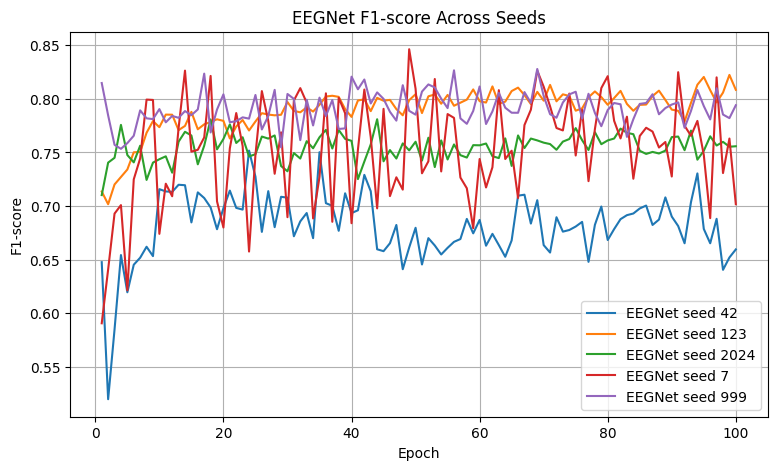

In [164]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
for seed, hist in eegnet_histories.items():
    plt.plot(hist["epoch"], hist["test_f1"], label=f"EEGNet seed {seed}")

plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("EEGNet F1-score Across Seeds")
plt.legend()
plt.grid(True)
plt.show()

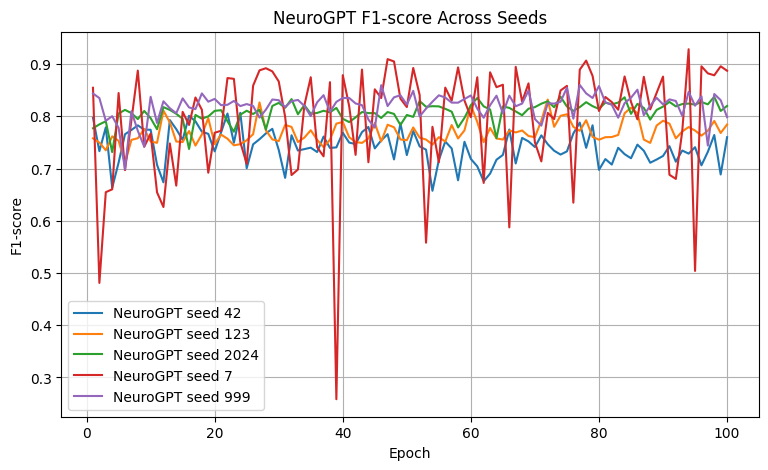

In [165]:
plt.figure(figsize=(9, 5))
for seed, hist in neurogpt_histories.items():
    plt.plot(hist["epoch"], hist["test_f1"], label=f"NeuroGPT seed {seed}")

plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("NeuroGPT F1-score Across Seeds")
plt.legend()
plt.grid(True)
plt.show()

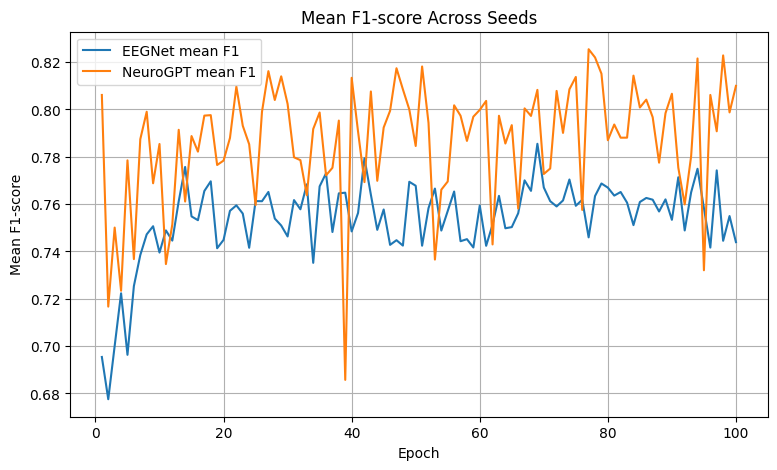

In [166]:
mean_curves = []

for model_name, histories in [
    ("EEGNet", eegnet_histories),
    ("NeuroGPT", neurogpt_histories),
]:
    tmp = pd.concat(histories.values(), ignore_index=True)
    curve = tmp.groupby("epoch")["test_f1"].agg(["mean", "std"]).reset_index()
    curve["model"] = model_name
    mean_curves.append(curve)

mean_curves_df = pd.concat(mean_curves, ignore_index=True)

mean_curves_df.to_csv(
    "mean_f1_curves_eegnet_neurogpt_80_20.csv",
    index=False
)

plt.figure(figsize=(9, 5))

for model_name in mean_curves_df["model"].unique():
    sub = mean_curves_df[mean_curves_df["model"] == model_name]
    plt.plot(sub["epoch"], sub["mean"], label=f"{model_name} mean F1")

plt.xlabel("Epoch")
plt.ylabel("Mean F1-score")
plt.title("Mean F1-score Across Seeds")
plt.legend()
plt.grid(True)
plt.show()

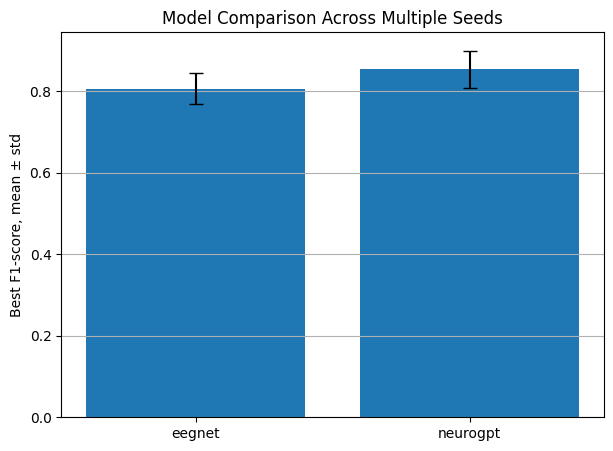

In [167]:
plot_df = all_seed_results_df.groupby("model")["f1"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(7, 5))
plt.bar(plot_df["model"], plot_df["mean"], yerr=plot_df["std"], capsize=5)
plt.ylabel("Best F1-score, mean ± std")
plt.title("Model Comparison Across Multiple Seeds")
plt.grid(axis="y")
plt.show()